In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Names and NetID
# Vedaant Magow - vmagow2
# Dhruv Vohra - dhruvv4
# Brian Keating - brianmk3

In [2]:
# Task 0 part 1
import pandas as pd

# Load the raw dictionary
raw_dict = pd.read_pickle("delta_a100_gpu_xid_dataset.pkl") #equivalent to opening file using "rb" and using the "pickle.load" function

In [3]:
# Task 0 part 2
march_10_2024_errors = raw_dict["2024-03-10"]  # retrive list of all errors on desired date from dictionary

# part 2a
print("Total XID errors on March 10, 2024:", len(march_10_2024_errors)) # len() of this list will give total number of errors on date

# part 2b
# obtain the XID of every error from the date
xids = []
for entry in march_10_2024_errors: 
    xids.append(entry["XID"])
unique_xids = list(set(xids)) # conversion to set removes duplicates, then convert back to list for output
print("Unique XID list:", unique_xids)

Total XID errors on March 10, 2024: 87
Unique XID list: [74, 43, 45, 13, 119, 31]


In [4]:
# Task 0 part 3
# Flatten the dictionary into a single list of all errors
all_errors = []
for date, error_list in raw_dict.items():
   for i in error_list:
      i["Date"] = date
      all_errors.append(i)

# Convert that list into a Pandas DataFrame
df = pd.DataFrame(all_errors)
df = df[["Date", "datetime", "timestamp", "node_name", "device_id","XID","Tag"]] # reorders columns in desired format
df = df.sort_values(by = 'timestamp') # sorts by increasing timestamp
df.head() # view the first few entries 

,Date,datetime,timestamp,node_name,device_id,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING


In [5]:
!pip install matplotlib

In [6]:
# Task 1 part 1 
# print the first 10 rows (already in increasing order by timestamp)
df.head(10) 

,Date,datetime,timestamp,node_name,device_id,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
6,2022-07-17,2022-07-17T11:27:40.849346-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
7,2022-07-17,2022-07-17T12:10:20.898006-05:00,1.658078e+09,gpua072,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
8,2022-07-17,2022-07-17T13:21:30.008143-05:00,1.658082e+09,gpua081,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
9,2022-07-17,2022-07-17T13:21:34.279469-05:00,1.658082e+09,gpua005,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


In [7]:
# Task 1 part 1 cont.
# first timestamp in both unix and human-readable datetime
unix_time = df.iloc[0]["timestamp"]
human_readable = pd.to_datetime(unix_time, unit='s')
print("first time stamp in Unix is ", unix_time)
print("first time stamp in human readable format is ", human_readable)

first time stamp in Unix is  1658071647.4228365
first time stamp in human readable format is  2022-07-17 15:27:27.422836542


In [8]:
# Task 1 part 2a

count_XID_43 = df[df['XID'] == 43] # number of errors with XID = 43
print('errors with XID equals 43:' , len(count_XID_43))

total = len(df) # total rows
print('all rows total:' , total)

# Prob XID 43 = Number of times XID is 43 / Total Amount of Rows of Data
Probability_Task1_Part2a = len(count_XID_43)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2a)

errors with XID equals 43: 8592
all rows total: 73514
probability that XID = 43 when random sample: 0.11687569714612182


In [9]:
# Task 1 part 2b

count_XID_119 = df[df['XID'] == 119] # number of errors with XID = 119
print('errors with XID equals 119:' , len(count_XID_119))

print('all rows total:' , total) # total rows

# same probability formula as part 2a
Probability_Task1_Part2b = len(count_XID_119)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2b)

errors with XID equals 119: 1303
all rows total: 73514
probability that XID = 43 when random sample: 0.017724515058356233


In [10]:
# task 1 part 2c
# user error is way more likely than hardware error 0.116>0.0177

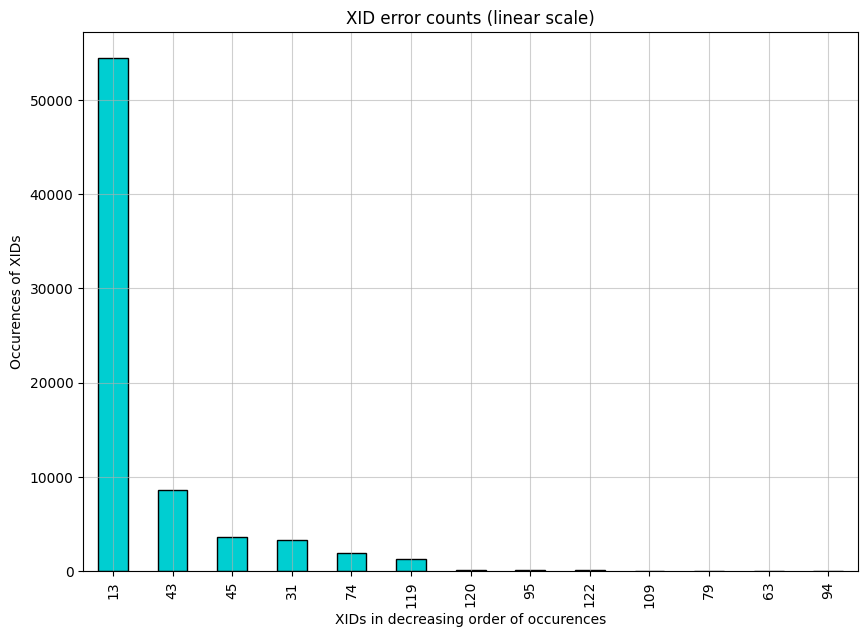

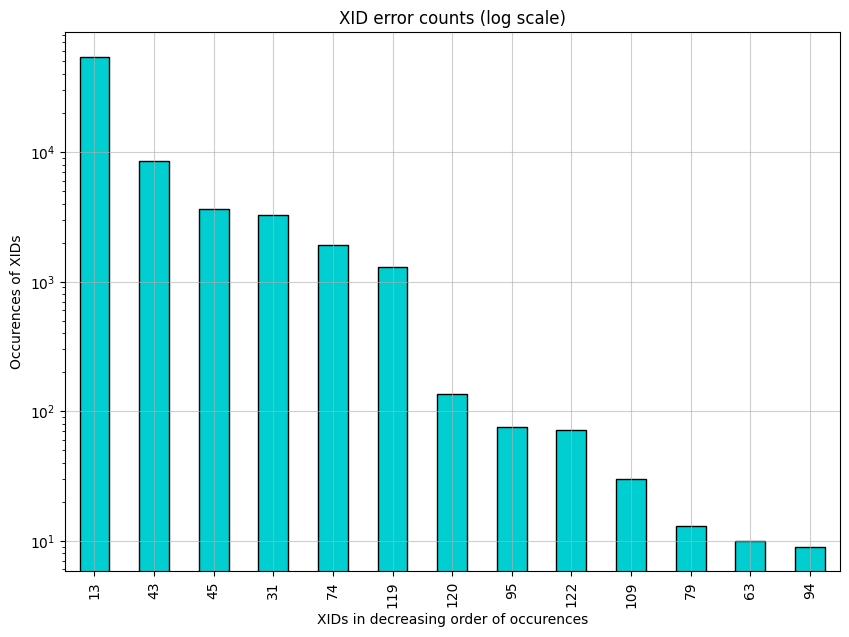

In [11]:
# Task 1 Part 3
import matplotlib.pyplot as plt

# count occurences of each XID to sort and plot
plot_errorXIDs = df['XID'].value_counts()

# plot with linear y-axis scale
plt.figure(figsize=(10,7))
plot_errorXIDs.sort_values(ascending = False).plot(kind = 'bar', color = 'darkturquoise' , edgecolor = 'black' ) 
plt.title("XID error counts (linear scale)")
plt.xlabel('XIDs in decreasing order of occurences')
plt.ylabel('Occurences of XIDs')
plt.grid(axis = 'x', linestyle = '-', alpha = 0.6)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.6)
plt.show()

# plot with log y-axis scale
plt.figure(figsize=(10,7))
plot_errorXIDs.sort_values(ascending = False).plot(kind = 'bar', color = 'darkturquoise' , edgecolor = 'black' ) 
plt.yscale('log') # key change to have log scale
plt.title("XID error counts (log scale)")
plt.xlabel('XIDs in decreasing order of occurences')
plt.ylabel('Occurences of XIDs')
plt.grid(axis = 'x', linestyle = '-', alpha = 0.6)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.6)
plt.show()

In [12]:
# Task 1 part 4a
# Based on the plot the most dominant XID is 13. 

# Task 1 part 4b
# Top 5 XIDs that occurred in the dataset are 13, 43, 45, 31 and 74

# Task 1 part 4c
# According to the study XID 74 is an interconnect error, Description according to study: 
# NVLink error indicating connection issues between GPUs via NVLink interconnection.
# Finding its Tag now
# to find the tag we located it using the XID and .unique() cause there are multiple errors with XID 74 
# unique just makes it easy and returns 1(they have the same tags)
# also .unique() returns an array so [0] is used to access the only element
tag_74 = df.loc[df['XID'] == 74, 'Tag'].unique()[0]
print("tag for XID 74 is ", tag_74)

tag for XID 74 is  074_NVLINK_error


In [13]:
# Task 1 part 5a
# making histogram of timestamps using .diff
# since we have the timestamps we use .diff() on the columns, this calculates the diff between the current and previous row. 
# We exactly need to plot this because each row is a new error and we need the time between each consecutive error

time_intervals = df["timestamp"].diff()
print(time_intervals)

# removing the NaN value that can be seen below.
# This is needed for the other math related functions that are to come.

time_intervals = time_intervals.dropna()

0                NaN
1         121.881796
2        2021.788913
3          64.714361
4         398.010359
            ...     
73509    2046.415668
73510     331.060869
73511     716.815888
73512     329.312100
73513     834.598951
Name: timestamp, Length: 73514, dtype: float64


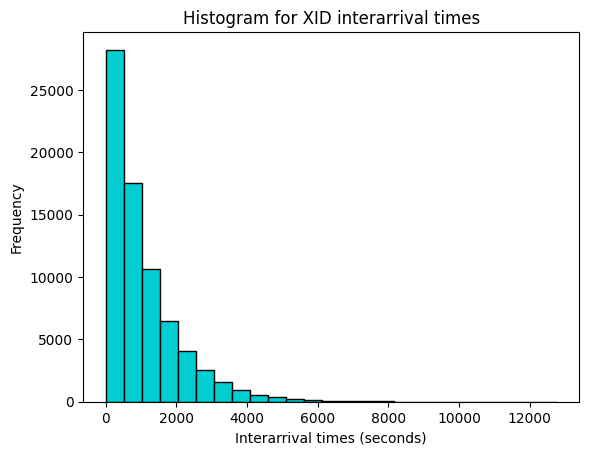

the mean interarrival time in seconds is 1054.4875208708004
the standard deviation in seconds is 1061.687541810317


In [14]:
# plotting histogram (continuing Task 1 part 5a)
plt.hist(time_intervals, bins = 25, color = 'darkturquoise',edgecolor  = 'black')
plt.title("Histogram for XID interarrival times")
plt.ylabel("Frequency")
plt.xlabel("Interarrival times (seconds)")
plt.show()

# Task 1 part 5b
# easy to calculate mean and standard deviation with inbuilt functions
mean_time = time_intervals.mean()
print("the mean interarrival time in seconds is", mean_time)
time_interval_std = time_intervals.std()
print("the standard deviation in seconds is", time_interval_std)

In [15]:
# Task 1 part 5c
# since the entire system is being used and every XID is critical,
# the average time a user would be able to run their job before being interrupted by an XID is the same as the MEAN = 1054.49 seconds

In [16]:
# for Task 1 part 6 we used the .goodness_of_fit() function from scipy.stats 
# this made it very easy to calulate the KS-statistic and P-value by just needing the time interval data.
# Task 1 part 6a
from scipy import stats
expon_output = stats.goodness_of_fit(stats.expon, time_intervals, statistic='ks', n_mc_samples = 500)
print(f"Exponential Distribution: KS-statistic ={expon_output.statistic}, P-value = {expon_output.pvalue}")

Exponential Distribution: KS-statistic =0.0027587078476604687, P-value = 0.4091816367265469


In [17]:
# Task 1 part 6b
norm_output = stats.goodness_of_fit(stats.norm, time_intervals, statistic='ks', n_mc_samples = 150)
print(f"Normal Distribution: KS-statistic = {norm_output.statistic}, P-value = {norm_output.pvalue}")

Normal Distribution: KS-statistic = 0.160304403757268, P-value = 0.006622516556291391


In [18]:
# Task 1 part 6c 
uni_output = stats.goodness_of_fit(stats.uniform, time_intervals, statistic='ks', n_mc_samples = 150)
print(f"Uniform Distribution: KS-statistic = {uni_output.statistic}, P-value =  {uni_output.pvalue}")

Uniform Distribution: KS-statistic = 0.7107835116555101, P-value =  0.006622516556291391


In [19]:
#Task 1 part 6d
lognorm_output = stats.goodness_of_fit(stats.lognorm, time_intervals, statistic='ks', n_mc_samples = 150)
print(f"Lognormal Distribution: KS-statistic = {lognorm_output.statistic}, P-value = {lognorm_output.pvalue}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


Lognormal Distribution: KS-statistic = 0.03545989968959484, P-value = 0.9602649006622517


In [20]:
# The goodness of fit function returns a p-value and a KS-statistics. In statistics, we often
# reject a fitting distribution if the p-value is less than 0.05.
# as can be seen above, normal and uniform are rejected since their p-values are less than 0.05. 
# Among the ones that are not rejected, we prefer the one with the lowest KS-statistics, which indicates a tighter fit.
# Since the exponential distribution has a lower KS statistic (0.0027587078476604687 < 0.03545989968959473), we select exponential as the best fit

In [21]:
# Finding best fit parameters for the exponential distribution using an inbuilt function.
# It returns a tuple hence we use [] to access the needed parameters
best_fit_params = stats.expon.fit(time_intervals)
print(f"Best fit params are: location = {best_fit_params[0]}, scale = {best_fit_params[1]}")

Best fit params are: location = 0.011411905288696289, scale = 1054.4761089655117


In [22]:
# Task 1 part 7a
# The distribution for the number of errors in 1 hour is Poisson

# Task 1 part 7b
# this distribution has 1 paramater, lambda, and is calculated below
# used scale param from part 6, reciprocal of it gives average number of errors per second, multiply by 3600 for per hour
lamb = (1 / best_fit_params[1]) * 3600 
print(f"lambda = {lamb}")

lambda = 3.4140176049429525


In [23]:
# Task 1 part 7c
from scipy.stats import poisson
# P(X<=5) must be at least 0.8
prob = poisson.cdf(5, lamb) # use poisson cdf to find the above probability
print(f"Probability of at most 5 errors in 1 hour:{prob}");
# since this probability is greater than 0.8, the system meets the user's requirement. 

Probability of at most 5 errors in 1 hour:0.8687652653638035


In [24]:
# Task 2 part 1:
# The interarrival distribution we have fitted from Task 1 parts 6 and 7 is:
# Exponential Distribution, and its best-fit paramaters were calculated to be:
# location = 0.011411905288696289, scale = 1054.4761089655117
# The main Parameter, Lambda, is calclated as follows:
lamb = (1 / best_fit_params[1]) # this is (1 / scale)
print(f"Lambda for our Exponential distribution: {lamb}")
# So yes, we agree with the TA that the Exponential distribution is a good fit
# Since we answered yes, we will skip task 2 part 2.

Lambda for our Exponential distribution: 0.0009483382235952645


In [25]:
# Task 2 part 3a:
# Empirical MTBF = Total Operational Hours / # of failure events
total_operational_seconds = df["timestamp"].max() - df["timestamp"].min() # timestamp is time in seconds
total_operational_hours = total_operational_seconds / 3600
failure_events = len(df) # each entry in the df is a failure
empirical_mtbf = total_operational_hours / failure_events
print(f"MTBF in hours: {empirical_mtbf} hours")

MTBF in hours: 0.292909215787224 hours


In [26]:
# Task 2 part 3b:
# Convert MTBF in hours to seconds by multiplying by 3600, (3600 seconds per hour)
empirical_mtbf_seconds = empirical_mtbf * 3600
print(f"MTBF in seconds: {empirical_mtbf_seconds} seconds")

MTBF in seconds: 1054.4731768340064 seconds


In [27]:
# Task 2 part 4:
# The mean of the exponential distribution (interarrival times distribution) will be the MTBF
exponential_mtbf_seconds = best_fit_params[1] # scale is the mean of the distribution
exponential_mtbf_hours = exponential_mtbf_seconds / 3600
print(f"MTBF derived from fitted exponential distribution: {exponential_mtbf_seconds} seconds or {exponential_mtbf_hours} hours")
print(f"difference between mtbfs in seconds (exponential - empirical): {exponential_mtbf_seconds - empirical_mtbf_seconds} seconds")

MTBF derived from fitted exponential distribution: 1054.4761089655117 seconds or 0.2929100302681977 hours
difference between mtbfs in seconds (exponential - empirical): 0.0029321315053039143 seconds


In [28]:
# Task 2 part 4 a:
# The two MTBFs are nearly identical, suggesting that the scale paramater (mean of the exponential distribution) 
# is approximately equal to the MTBF of the actual data (empirical MTBF)

# Task 2 Part 4 b:
# The relationship found in part a shows that the averages of the distribution and actual data are consistent, 
# NOT that the exponential model is a good fit. We also need to confirm the shapes of the distribution and the actual data are consistent.
# We know the shapes are cosnsitent from the KS goodness of fit test from Task 1 part 6. 
# Since for the exponential distribution the p-value > 0.05 and the KS statistic is the lowest, 
# we know the shapes of the exponential distribution and the actual data match well.

In [44]:
# Task 2 part 5 a 
# sorting the interarrival times found
import numpy as np
sorted_time_intervals = time_intervals.sort_values(ascending = True)
unique_time_intervals = sorted_time_intervals.unique()
print(unique_time_intervals)
#Number of unique interarrival times
print("Number of unique interarrival times:", time_intervals.nunique(), len(unique_time_intervals))

[1.14119053e-02 2.75630951e-02 5.46200275e-02 ... 1.15492292e+04
 1.18391051e+04 1.27569612e+04]
Number of unique interarrival times: 73512 73512


In [ ]:
# Task 2 part 5 b

#sorted intervals are in a key value pair so getting just the values which we need
time_values = sorted_time_intervals.values

n = len(time_values)
Ht = []
c_hazard = 0
i = 0
while i<n:
    t_int = time_values[i] # Current time interval
    Di = 0 # Number of occurences for current time interval
    temp = i
    while temp<n:
        if time_values[temp] == t_int:
            Di +=1
            temp +=1
        if temp < n  and time_values[temp] > t_int:
            break
    Yi = n - i # Number of items in list greater than or equal to current time interval

    c_hazard += Di/Yi

    for j in range(Di):
        Ht.append(c_hazard)
    i +=Di
print("first ten values for the cumulative hazard are:")
print(Ht[:10])

first ten values for the cumulative hazard are
[1.3603036197679321e-05, 2.7206257440469614e-05, 4.080966373340536e-05, 5.441325508152126e-05, 6.801703148985221e-05, 8.162099296343331e-05, 9.522513950729989e-05, 0.00010882947112648744, 0.0001224339878260317, 0.00013603868961096856]


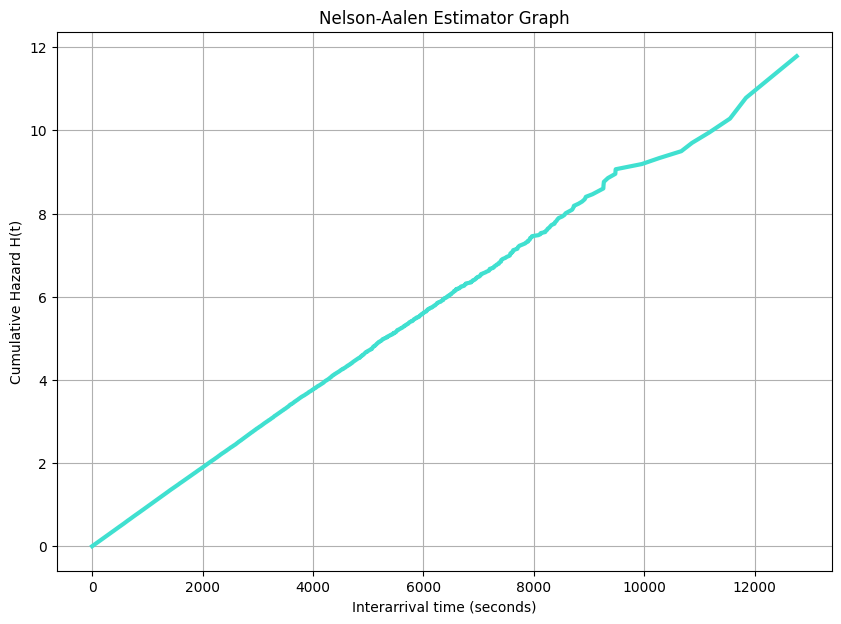

In [75]:
# Task 2 part 5 c

plt.figure(figsize=(10,7))
plt.plot(time_values, Ht, color='turquoise',linewidth='3')
plt.title("Nelson-Aalen Estimator Graph")
plt.xlabel("Interarrival time (seconds)")
plt.ylabel("Cumulative Hazard H(t)")
plt.grid(True, linestyle='-')

plt.show()

In [ ]:
# the graph above is approximately linear, it increases at a linear rate and the cumulative hazard is predictable.
#  And since the slope is also constant the instantaneous failure rate can be viewed as constant